In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
import globals as gl

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

SMA------------------
Pearson's r: 0.04980807479809805+/-0.011920198972452922
group estimate:-0.9999999703089181 central 95% CI for r: [-1.000, -1.000]
PMd------------------
Pearson's r: 0.1603620982022448+/-0.01782616381852426
group estimate:-0.3579002187218182 central 95% CI for r: [-0.649, -0.170]
PMv------------------
Pearson's r: 0.08790654134723044+/-0.03058793549840301
group estimate:-1.0 central 95% CI for r: [-1.000, -0.566]
M1------------------
Pearson's r: 0.4229177674863719+/-0.05237103385220298
group estimate:0.6329187001514598 central 95% CI for r: [0.516, 0.713]
S1------------------
Pearson's r: 0.49757039219096916+/-0.04960664845549519
group estimate:0.6115209015521293 central 95% CI for r: [0.468, 0.728]
SPLa------------------
Pearson's r: 0.09907750922312182+/-0.01707012366690061
group estimate:-0.7898913905838213 central 95% CI for r: [-1.000, -0.593]
SPLp------------------
Pearson's r: 0.08600884088161519+/-0.016996316530465745
group estimate:-1.0 central 95% CI for

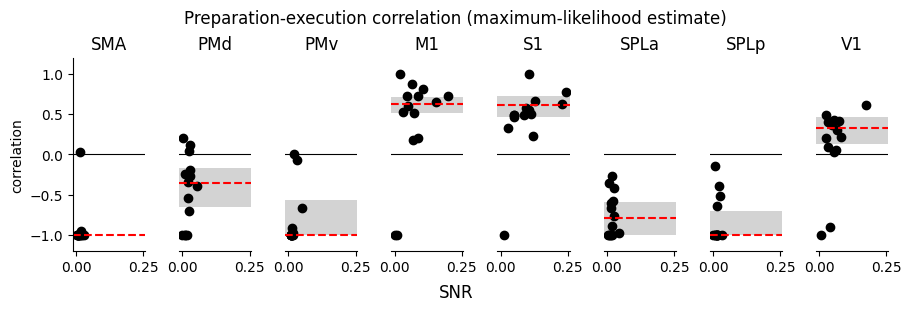

In [3]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(9, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    print(f'{roi}------------------')
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.corr_plan-exec.glm{glm}.{H}.{roi}.npy'))
    sigma2_1 = G[:, 0, 0]
    sigma2_2 = G[:, 1, 1]
    cov = G[:, 0, 1]
    corr = cov / np.sqrt(sigma2_1 * sigma2_2)
    print(f"Pearson's r: {corr.mean()}+/-{corr.std() / np.sqrt(corr.shape[0])}")
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr_plan-exec.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'r_bootstrap.corr_plan-exec.{H}.{roi}.npy'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr_plan-exec.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Preparation-execution correlation (maximum-likelihood estimate)')

plt.show()


group estimate:-0.9999999999906445 central 95% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999999182 central 95% CI for r: [-1.000, -1.000]
group estimate:-0.999999999999805 central 95% CI for r: [-1.000, -1.000]
group estimate:-0.8232093652196346 central 95% CI for r: [-1.000, -0.685]
group estimate:-0.6134584479664559 central 95% CI for r: [-0.933, -0.536]
group estimate:-0.9999999999998316 central 95% CI for r: [-1.000, -1.000]
group estimate:-0.9999999923223722 central 95% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999999051 central 95% CI for r: [-1.000, -1.000]


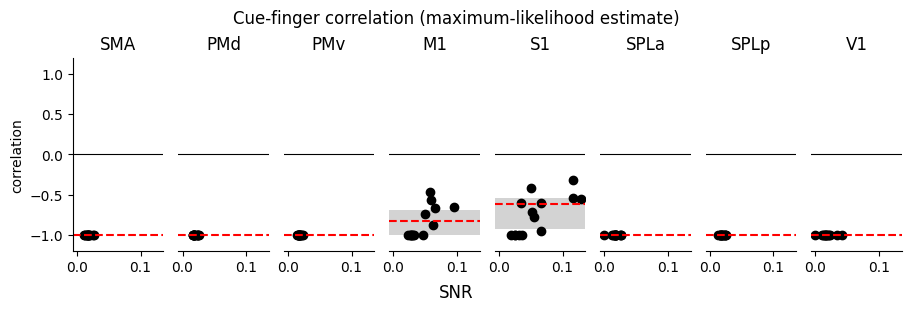

In [4]:
fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(9, 3), constrained_layout=True, sharey=True)

for r, roi in enumerate(rois):
    print(f'{roi}------------------')
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.corr_cue-finger.glm{glm}.{H}.{roi}.npy'))
    sigma2_1 = G[:, 0, 0]
    sigma2_2 = G[:, 1, 1]
    cov = G[:, 0, 1]
    corr = cov / np.sqrt(sigma2_1 * sigma2_2)
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr_cue-finger.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'r_bootstrap.corr_cue-finger.{H}.{roi}.npy'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr_cue-finger.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Cue-finger correlation (maximum-likelihood estimate)')

plt.show()
